# A/B test analysis

## Project description

This project is also available on kaggle platform: [A/B-test analysis](https://www.kaggle.com/code/alenakn/a-b-test-analysis/notebook)

The project is based on the 'Cookie Cats Dataset', which is originally from a DataCamp mini project and available on [kaggle](https://www.kaggle.com/code/yufengsui/datacamp-project-mobile-games-a-b-testing/input).

The Cookie Cats game was developed by Tactile Games. It currently has over 1 million downloads on [Google Play](https://play.google.com/store/apps/details?id=dk.tactile.cookiecats) with mostly excellent reviews.

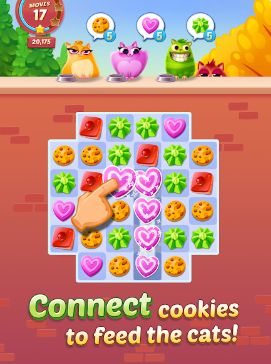

Monetization of the app is built in the following way. As players progress through the levels of the game, they will occasionally encounter gates that force them to wait a non-trivial amount of time or make an in-app purchase to progress. First of all, this feature drives in-app purchases. But these gates also give players an enforced break from playing the game. This leads to higher retention for the game, as the player has no opportunity to go through the game immediately.

The subject of the AB-test is the level at which the first gate are placed. Initially, the first gate was set at level 30. It is proposed to move the first gate from level 30 to level 40 in order to increase the retention metric.

**Hypothesis**:

H0(Null hypothesis): Moving the first gate from level 30 to level 40 will not affect the 7-Day Retention.

H1(Alternative hypothesis): Moving the first gate from level 30 to level 40 will have an effect on 7-Day Retention (two-sided alternative).

## Imports and loading data

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import math

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/ElenaNKn/data_projects/refs/heads/master/project_ab_testing/cookie_cats.csv')

In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
# check for NA elements
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [6]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


The standard deviation of `sum_gamerounds` is rather large, and the maximum value is much higher than the 75% quantile. This may point to some problems with the data. Let's check for inconsistent data.

In [7]:
df.sum_gamerounds.value_counts().reset_index().sort_values('sum_gamerounds', ascending = False).head(7)

,sum_gamerounds,count
874,49854,1
855,2961,1
736,2640,1
810,2438,1
831,2294,1
818,2251,1
732,2156,1


User with `'sum_gamerounds' = 49854` seems to be a test user, as his `sum_gamerounds` is extraordinary higher than `sum_gamerounds` of other users. Since the behavior of this user is not typical, we'll exclude him.

In [8]:
df = df[df['sum_gamerounds'] != 49854]

## Experiment design

The design stage wasn't considered in the DataCamp project from which the dataset was taken. But it is essential to determine the target metric, the effect we want to detect, and to calculate the sample size. So let's consider the design as we would if we were performing this experiment in reality.

Suppose we want to increase the 7-Day Retention by moving the first gate from level 30 to level 40. Then the metrics under investigation will be:
- **target metric** (metric we want to increase) - 7-Day Retention;
- **guardrail metric** (metric used to prevent negative side effects from experiment, we don't want to drop it down) - 1-Day Retention

Now we need to set the effect, we want to depect and calculate the sample size of experiment groups. In real life we'd use hystorical data for this purpose. But as we don't have such opportinity, we'll make point estimation of 7-day Retention on the base of group with `version = 'gate_30'`

In [9]:
point_est = df[(df.version == 'gate_30') & (df.retention_7)].shape[0] / df[df.version == 'gate_30'].shape[0]
point_est

0.19018322557551623

Let's suppose that we expect that 7-day retention will grow from 19% to 20%, and we want to detect this growth with 95% probability. Then the sample size per group will be calculated based on the following function:

In [10]:
def sample_size(
    baseline_rate=0.19,
    expected_lift=0.01,
    alpha=0.05,      # significance level
    power=0.80,      # 1 - beta
    alternative='two-sided'
):
    """
    Sample size per group for a A/B test.
    
    Parameters:
    - baseline_rate: historical 
    - expected_lift: expected absolute increase of rate
    - alpha: confidence level 
    - power: statistical power (default 0.80)
    - alternative: 'two-sided' or 'one-sided'
    
    Returns:
    - n_samples: required sample size per variant
    """
    p1 = baseline_rate
    p2 = baseline_rate + expected_lift
    
    p_pool = (p1 + p2) / 2
    
    # Z-scores
    if alternative == 'two-sided':
        z_alpha = stats.norm.ppf(1 - alpha/2)
    else:  
        z_alpha = stats.norm.ppf(1 - alpha)
    
    z_beta = stats.norm.ppf(power)
    
    # Sample size formula for two proportions
    # n = (z_alpha * sqrt(2 * p_pool * (1 - p_pool)) + z_beta * sqrt(p1*(1-p1) + p2*(1-p2)))^2 / (p2 - p1)^2
    n_numerator = (z_alpha * math.sqrt(2 * p_pool * (1 - p_pool)) +
                 z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    n_denominator = (p2 - p1) ** 2
    
    n_samples = math.ceil(n_numerator / n_denominator)
    
    return n_samples

In [11]:
n_samples = sample_size(
    baseline_rate=point_est,
    expected_lift=0.01,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print(f"Required sample size per group: {n_samples}")
print(f"Total sample size: {n_samples * 2}")

Required sample size per group: 24658
Total sample size: 49316


Let's check how large given dataset is

In [12]:
df.groupby('version').agg(
    users = ('userid', 'nunique')
)

,users
version,
gate_30,44699
gate_40,45489


The given dataset is much larger, than we needed. In most cases userid are assigned to users directly users directly after registration. The higher `userid` value is, the later user have registered. That is why we will form our groups by taking the n_samples smallest `userid` from every version.

*Actually in real life test we should take a little bit more samples, as claning of ouliers may be needed (for example, by IQR or MDE methods). But metric of this test doesn't demand specific cleaning*

In [13]:
group_a = df[df.version == 'gate_30'].sort_values('userid').head(25000)
group_b = df[df.version == 'gate_40'].sort_values('userid').head(25000)

In [14]:
group_a.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
6,1066,gate_30,0,False,False
11,2101,gate_30,0,False,False
13,2179,gate_30,39,True,False


## Homogeneity check

In a real-life dataset, we need to check the homogeneity of data for different features, for example, user properties. We should be sure that, for features not affected by the experiment, our A and B groups are alike at a given significance level.

In the dataset under investigation, the only feature we have is the sum of gamerounds. At the level of the entire dataset, this feature may be affected by the experiment. However, for users who did not reach 30 gamerounds, our A and B groups should be similar. That’s why we may check the homogeneity of users from group_a and group_b who have fewer than 30 gamerounds (mostly to show the fact that homoheinity check should be performed).

Since the sum of gamerounds is a categorical value, the homogeneity check may be performed with a chi-squared statistical test. However, the Kolmogorov–Smirnov test is also appropriate for this task. Let's check both tests.

**Chi-square test**

In [15]:
from scipy.stats import chi2_contingency

df_check = df[(df.userid.isin(group_a.userid) | df.userid.isin(group_b.userid)) & (df.sum_gamerounds < 30)][['version', 'sum_gamerounds']] 

# Contingency table
contingency_table = pd.crosstab(
    df_check['version'],
    df_check['sum_gamerounds']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Distributions are homogeneous: {'Yes' if p_value > 0.05 else 'No'}")

Chi-square statistic: 26.1951
P-value: 0.6150
Distributions are homogeneous: Yes


**Kolmagorov-Smirnov test**

In [16]:
from scipy.stats import ks_2samp

In [17]:
statistic, p_value = ks_2samp(group_a[group_a.sum_gamerounds < 30][['sum_gamerounds']], group_b[group_b.sum_gamerounds < 30][['sum_gamerounds']])
print(f"P-value: {p_value[0]:.4f}")
print(f"Distributions are homogeneous: {'Yes' if p_value > 0.05 else 'No'}")

P-value: 0.4888
Distributions are homogeneous: Yes


So, users who didn't achieve the 30 gamerounds limit behaved similarly in groups A and B.

## AB-test analysis

The target metric (7-day retention) is binary. In such a case, we can use a two-proportion Z-test or a chi-square test to check if there is a statistically significant difference between variants. In this case, these two approaches are mathematically identical

In [25]:
# two-proportion Z-test

from statsmodels.stats.proportion import proportions_ztest

n_a = len(group_a)
n_b = len(group_b)
retention_a = group_a['retention_7'].sum()
retention_b = group_b['retention_7'].sum()
rate_a = retention_a / n_a
rate_b = retention_b / n_b

count = np.array([retention_a, retention_b])
nobs = np.array([n_a, n_b])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z = {z_stat:.4f}, p-value = {p_value:.6f}")
print(f"There is a statistically significant difference: {'Yes' if p_value < 0.05 else 'No'}")
print(f"Point estimate of average 7-Day Retention for group A = {rate_a:.6f}")
print(f"Point estimate of average 7-Day Retention for group B = {rate_b:.6f}")

Z = 2.9621, p-value = 0.003056
There is a statistically significant difference: Yes
Point estimate of average 7-Day Retention for group A = 0.191680
Point estimate of average 7-Day Retention for group B = 0.181360


From the result above, we see that the difference of 7-Day Retention between group A (where gate are at the level 30) and group B (where gate are at the level 40) is statistically significant. Moving the gate from 30-th level to 40-th resulted in the decrease of 7-day Retention from 19.17% to 18.14%

Let's also check the guardrail metric, 1-Day Retention. We will also use two-proportion Z-test 

In [27]:
n_a = len(group_a)
n_b = len(group_b)
retention_a = group_a['retention_1'].sum()
retention_b = group_b['retention_1'].sum()
rate_a = retention_a / n_a
rate_b = retention_b / n_b

count = np.array([retention_a, retention_b])
nobs = np.array([n_a, n_b])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z = {z_stat:.4f}, p-value = {p_value:.6f}")
print(f"There is a statistically significant difference: {'Yes' if p_value < 0.05 else 'No'}")
print(f"Point estimate of average 1-Day Retention for group A = {rate_a:.6f}")
print(f"Point estimate of average 1-Day Retention for group B = {rate_b:.6f}")

Z = 1.0975, p-value = 0.272403
There is a statistically significant difference: No
Point estimate of average 1-Day Retention for group A = 0.448760
Point estimate of average 1-Day Retention for group B = 0.443880


So moving of the gate from 30-th level to 40-th one didn't affect the 1-Day Retention

## Conclusions

1. The AB-test was designed based on the next initial assumptions:
   - we want to increase the 7-Day Retention by moving the first gate from level 30 to level 40;
   - the metrics under investigation are 7-Day Retention (target metric) and 1-Day Retention (guardrail metric, the metric we don't want to drop down);
   - we expect that due the proposed changes 7-day retention will grow from 19% to 20%, and we want to detect this growth with 95% probability.
2. The homogeneity check showed that users didn't achieve the 30 gamerounds limit behaved similarly in groups A and B (the distribution of the gamerounds sum is similar between A and B group)
3. The analysis of AB-test results showed that moving the gate from 30-th level to 40-th didn't affect the 1-Day Retention, but it resulted in a statistically significant decrease of 7-day Retention from 19.17% to 18.14%. 